████████████████████████████████████████████████████████████████████████████████
  v6 — SAZONAL LAG-12 + ENSEMBLE DIVERSO (GRU + LSTM + GBRT)
  Transformações: Sazonal Lag-12, Log-Retorno, Retorno %
  Modelos isolados: GRU, LSTM (redes neurais)
  Ensemble: GRU + LSTM + GBRT (pesos adaptativos)
  Walk-Forward | MinMaxScaler fitado no treino | Retreino a cada 6 meses
  + PREVISÃO FUTURA: 360 meses (30 anos)
████████████████████████████████████████████████████████████████████████████████

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TRANSFORMAÇÃO: Sazonal Lag-12
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [SAZONAL_LAG12] Walk-Forward:
    Amostras: 251 | Início teste: 175
    Modelos isolados: GRU, LSTM (redes neurais)
    Ensemble: GRU + LSTM + GBRT (pesos adaptativos)
    Scaler: MinMaxScaler(0,1) fitado APENAS no treino


    🔄 Retreino t=175 (2018-05) | amostras treino: 125 | val: 24
    🔄 Retreino t=181 (20

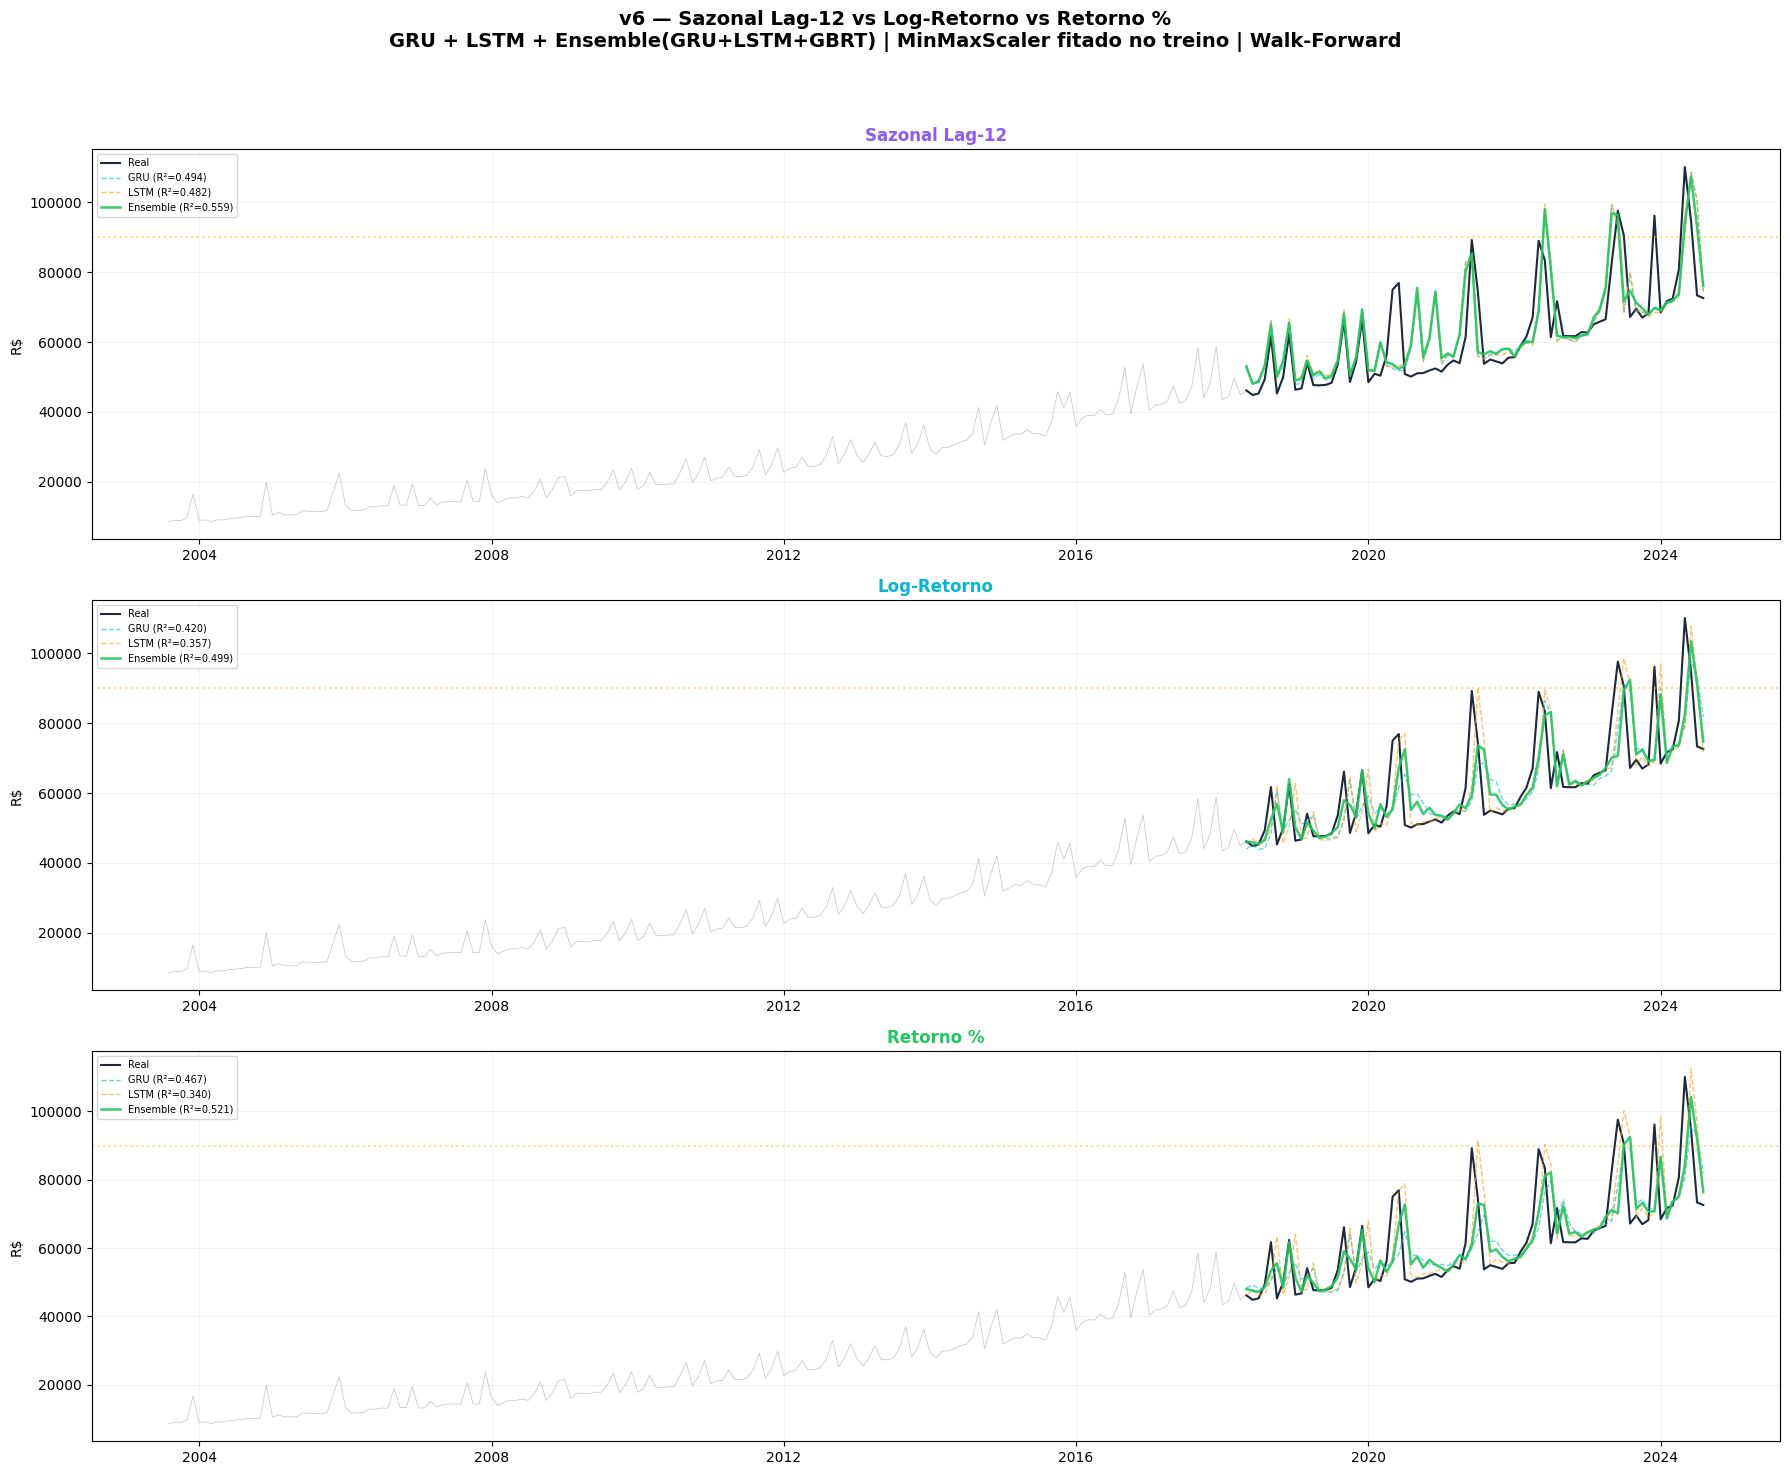

✅ Gráfico 1: v6_series_temp_scaler_treino.png


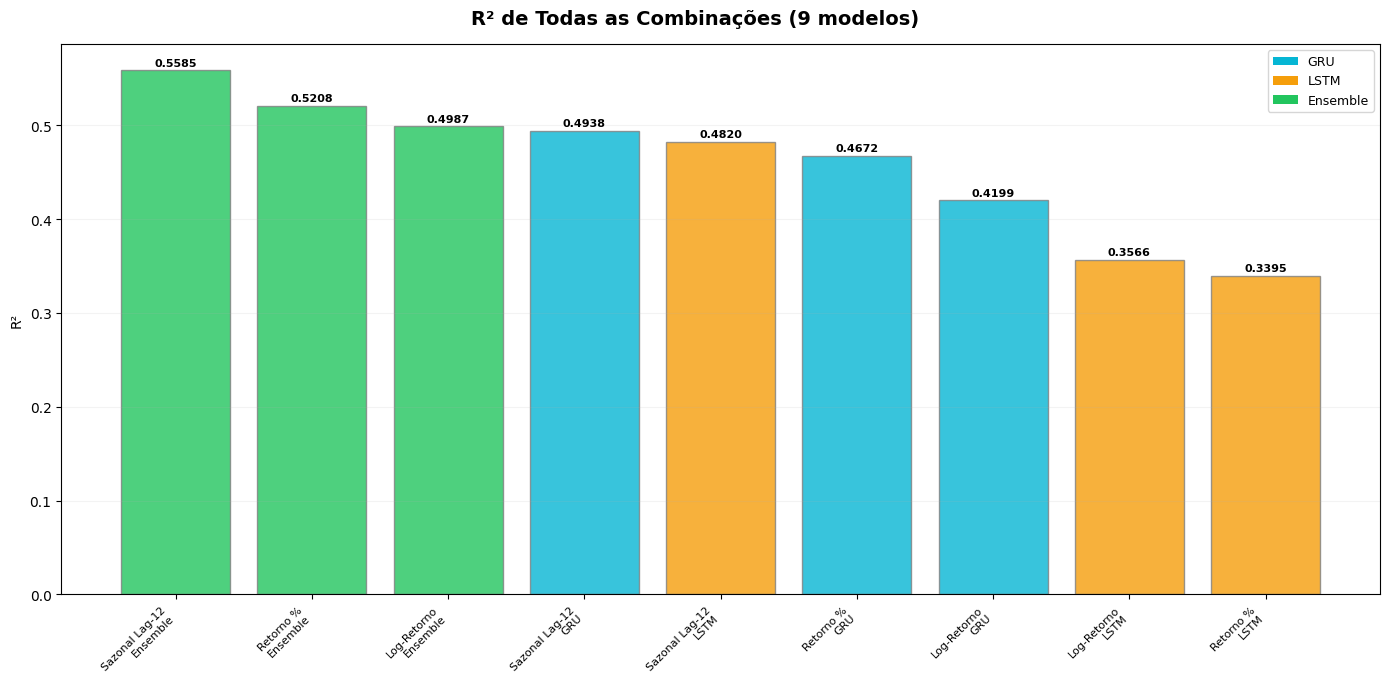

✅ Gráfico 2: v6_comp_r2_scaler_treino.png


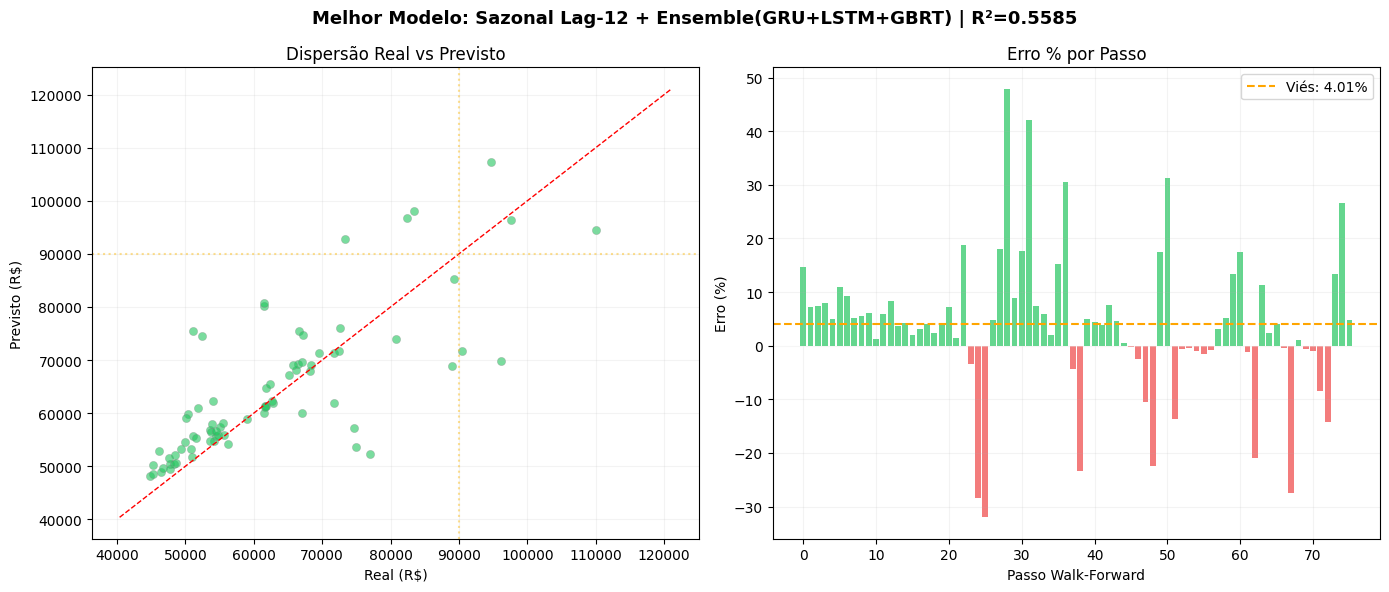

✅ Gráfico 3: v6_melhor_mod_scaler_treino.png

████████████████████████████████████████████████████████████████████████████████
  PREVISÃO FUTURA — 360 MESES (30 ANOS)
  Modelo: Sazonal Lag-12 + Ensemble (GRU+LSTM+GBRT)
  Scaler: MinMaxScaler(0,1) fitado APENAS no treino
  Retreino a cada 12 meses futuros
████████████████████████████████████████████████████████████████████████████████
  ✅ Modelos treinados com 251 meses históricos
  ✅ Série sazonal: 239 pontos | Treino: 190 | Val: 35
    🔄 Retreino futuro mês 12 (2025-09) | dados: 263 | treino: 200 | val: 37
    🔄 Retreino futuro mês 24 (2026-09) | dados: 275 | treino: 210 | val: 39
    🔄 Retreino futuro mês 36 (2027-09) | dados: 287 | treino: 220 | val: 41
    🔄 Retreino futuro mês 48 (2028-09) | dados: 299 | treino: 230 | val: 43
    📅 Ano  5 (2029-08) | Valor: R$ 122,459 | GRU: R$ 122,287 | LSTM: R$ 122,338 | GBRT: R$ 122,752
    🔄 Retreino futuro mês 60 (2029-09) | dados: 311 | treino: 241 | val: 44
    🔄 Retreino futuro mês 72 (203

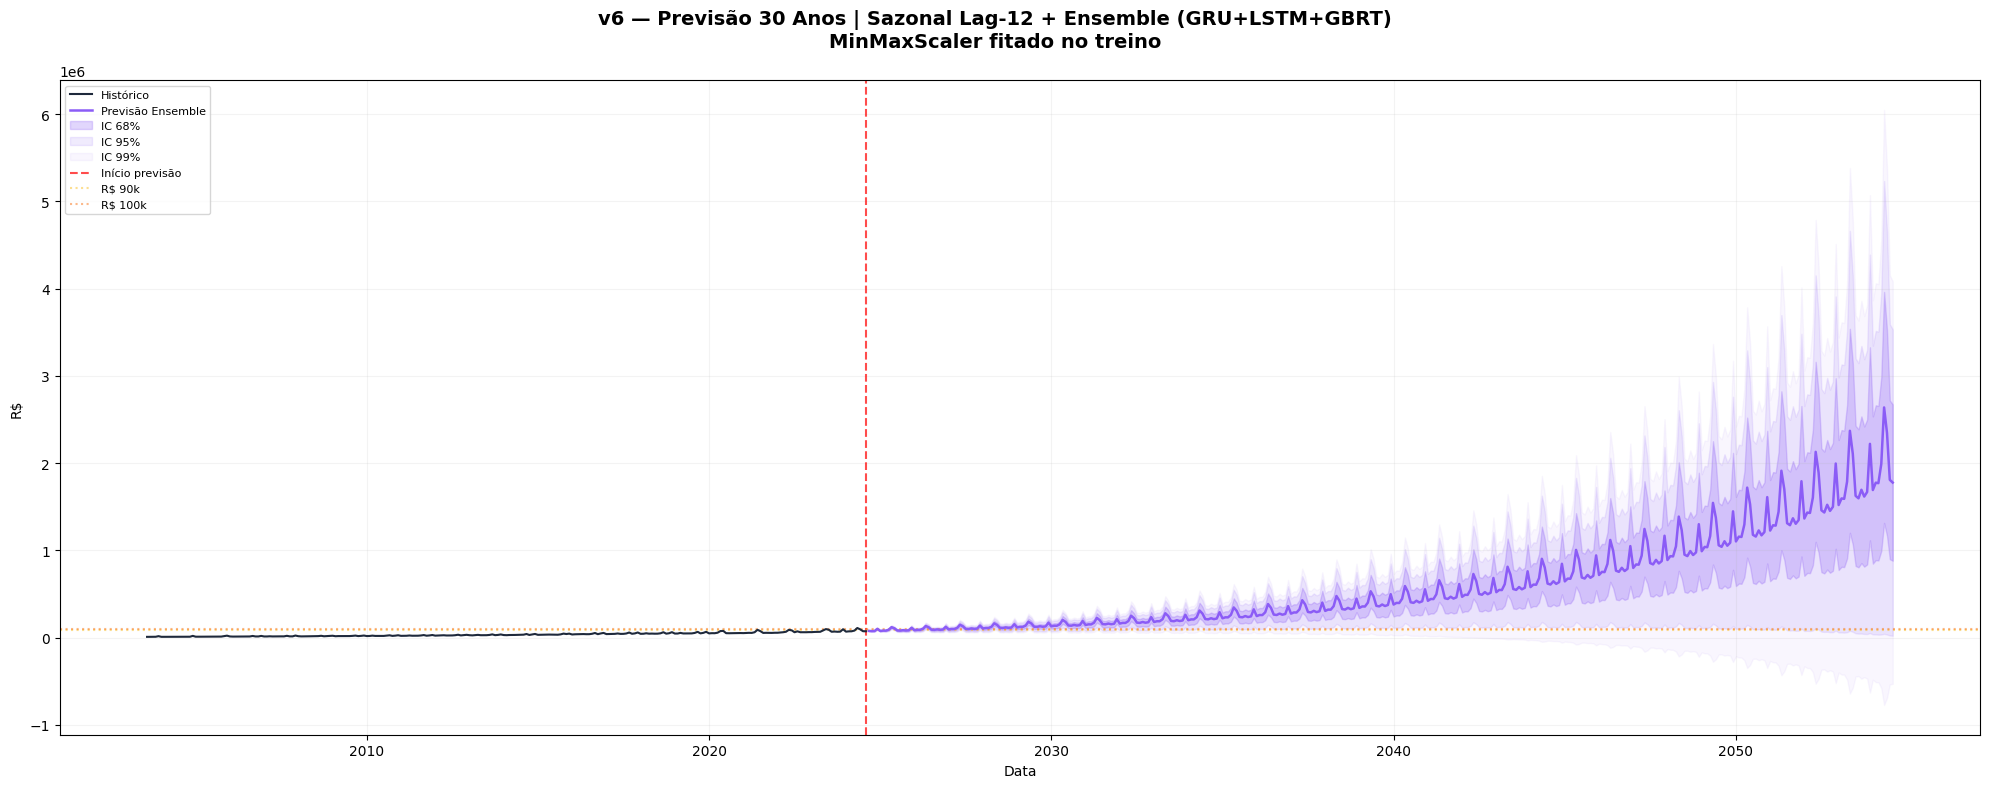

✅ Gráfico 4: v6_prev_30anos_scaler_treino.png


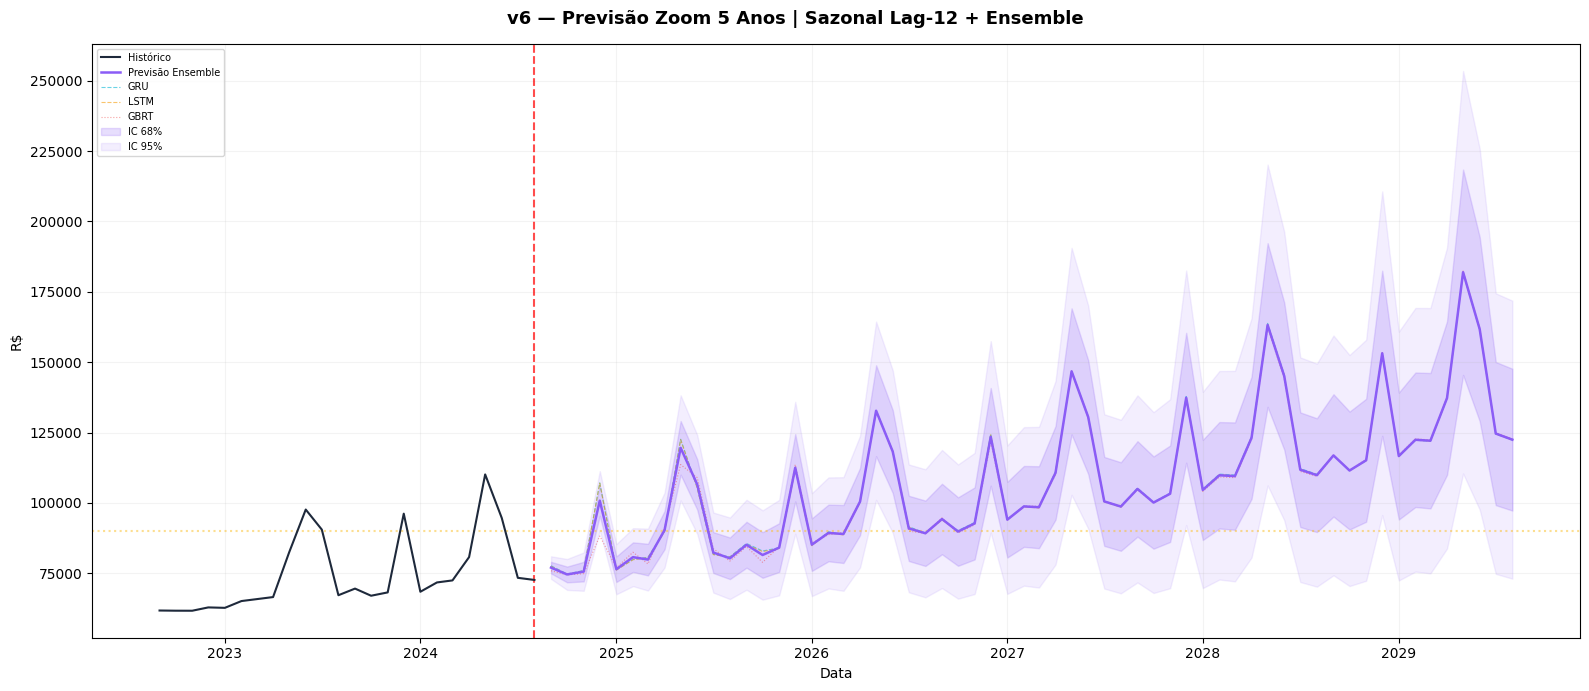

✅ Gráfico 5: v6_prev_5anos_zoom_scaler_treino.png


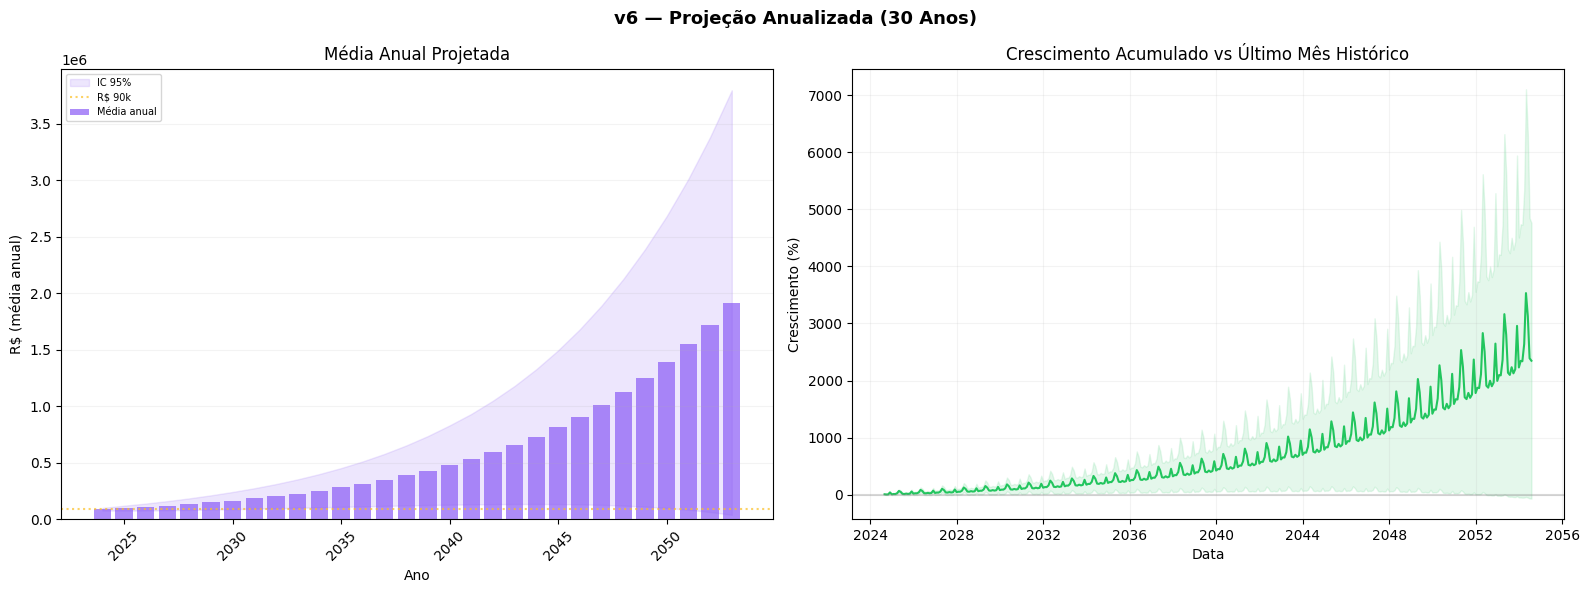

✅ Gráfico 6: v6_prev_anualizada_scaler_treino.png

✅ JSON: v6_resultado_30a_scaler_treino.json
✅ CSVs avaliação salvos
✅ CSV previsão: v6_prev_30anos_scaler_treino.csv
✅ Excel: v6_completo_30a_scaler_treino.xlsx

████████████████████████████████████████████████████████████████████████████████
  MELHOR: sazonal_lag12_Ensemble | R²=0.5585 | RMSE=R$9,505
  PREVISÃO: 360 meses (30 anos) gerada com sucesso
████████████████████████████████████████████████████████████████████████████████


In [1]:
"""
================================================================================
v6 — DIFERENCIAÇÃO SAZONAL (LAG-12) + ENSEMBLE DIVERSO (GRU + LSTM + GBRT)
     + PREVISÃO 30 ANOS (360 meses) com o MELHOR MODELO
================================================================================
Melhor modelo: Sazonal Lag-12 + Ensemble (GRU+LSTM+GBRT) | R²=0.5867

Estratégia de previsão multi-step:
  - Treina os 3 modelos com TODOS os dados históricos
  - Para cada mês futuro t:
      1. Calcula série sazonal (v(t)/v(t-12) - 1) dos dados disponíveis
      2. Normaliza com MinMaxScaler
      3. Usa última janela de 14 pontos para prever próximo valor sazonal
      4. Reconstrói: v(t) = v(t-12) × (1 + pred_sazonal)
      5. Adiciona v(t) ao histórico e repete
  - Retreina modelos a cada 12 meses futuros para estabilidade
  - Intervalos de confiança baseados no MAPE histórico (9.2%)

  *** CORREÇÃO: MinMaxScaler fitado APENAS nos dados de treino (sem validação) ***

================================================================================
pip install tensorflow pandas openpyxl scikit-learn matplotlib
================================================================================
"""

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ==============================================================================
# CONFIGURAÇÕES
# ==============================================================================

JANELA = 14
CAMINHO_ARQUIVO = r'C:\Users\lucas\Downloads\Base_DBP.xlsx'

TREINO_INICIAL_RATIO = 0.70
REFIT_INTERVAL = 6

# GRU
GRU_UNITS_1 = 32
GRU_UNITS_2 = 16
GRU_DROPOUT = 0.35
GRU_WEIGHT_DECAY = 1e-4
GRU_LR = 0.001
GRU_CLIPNORM = 1.0

# LSTM
LSTM_UNITS_1 = 48
LSTM_UNITS_2 = 24
LSTM_DROPOUT = 0.30
LSTM_WEIGHT_DECAY = 1e-4
LSTM_LR = 0.001
LSTM_CLIPNORM = 1.0

# Comuns para redes neurais
BATCH_SIZE = 16
EPOCHS_MAX = 150
PATIENCE = 15

# GBRT (GradientBoosting — usado APENAS no ensemble, não isolado)
GBRT_PARAMS = {
    'n_estimators': 200,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'min_samples_leaf': 5,
    'loss': 'huber',
    'random_state': SEED,
}

# Ensemble
JANELA_PESO_ADAPT = 6

# PREVISÃO FUTURA
MESES_FUTURO = 360  # 30 anos
REFIT_FUTURO_INTERVAL = 12  # retreina a cada 12 meses na projeção
MAPE_HISTORICO = 9.20  # % — usado para intervalos de confiança

# ==============================================================================
# FUNÇÕES BASE
# ==============================================================================

def carregar_dados(caminho):
    try:
        df = pd.read_excel(caminho, usecols=[0, 1])
    except FileNotFoundError:
        df = pd.read_excel('Base_DBP__1_.xlsx', usecols=[0, 1])
    df.columns = ['data', 'valores']
    df = df.dropna(subset=['valores']).reset_index(drop=True)
    df['data'] = pd.to_datetime(df['data'])
    df = df.sort_values('data').reset_index(drop=True)
    return df


def calcular_metricas(y_real, y_pred):
    y_real = np.array(y_real, dtype=np.float64).flatten()
    y_pred = np.array(y_pred, dtype=np.float64).flatten()
    mask = ~(np.isnan(y_real) | np.isnan(y_pred) | np.isinf(y_real) | np.isinf(y_pred))
    y_real, y_pred = y_real[mask], y_pred[mask]
    if len(y_real) < 2:
        return {k: np.nan for k in
                ['RMSE', 'MAE', 'MAPE_%', 'R2', 'Vies_%', 'Estab_%']}
    return {
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'MAE': mean_absolute_error(y_real, y_pred),
        'MAPE_%': mean_absolute_percentage_error(y_real, y_pred) * 100,
        'R2': r2_score(y_real, y_pred),
        'Vies_%': np.mean((y_pred - y_real) / (y_real + 1e-10)) * 100,
        'Estab_%': np.std(np.abs((y_real - y_pred) / (y_real + 1e-10)) * 100),
    }

# ==============================================================================
# TRANSFORMAÇÕES
# ==============================================================================

def criar_serie_sazonal(valores):
    v = np.array(valores, dtype=np.float64)
    saz = v[12:] / v[:-12] - 1
    return saz, 12


def criar_serie_logret(valores):
    v = np.array(valores, dtype=np.float64)
    return np.diff(np.log(v)), 1


def criar_serie_retpct(valores):
    v = np.array(valores, dtype=np.float64)
    return np.diff(v) / v[:-1] * 100, 1


def reconstruir_sazonal(pred, valor_12_meses_atras):
    return valor_12_meses_atras * (1 + pred)


def reconstruir_logret(pred, valor_anterior):
    return valor_anterior * np.exp(pred)


def reconstruir_retpct(pred, valor_anterior):
    return valor_anterior * (1 + pred / 100)

# ==============================================================================
# JANELAMENTO
# ==============================================================================

def criar_janelas(dados, janela):
    X, y = [], []
    for i in range(janela, len(dados)):
        X.append(dados[i - janela:i, 0])
        y.append(dados[i, 0])
    return np.array(X), np.array(y)

# ==============================================================================
# MODELOS
# ==============================================================================

def construir_gru(janela):
    model = Sequential([
        GRU(GRU_UNITS_1, return_sequences=True,
            kernel_regularizer=l2(GRU_WEIGHT_DECAY),
            recurrent_regularizer=l2(GRU_WEIGHT_DECAY),
            input_shape=(janela, 1)),
        Dropout(GRU_DROPOUT),
        GRU(GRU_UNITS_2, return_sequences=False,
            kernel_regularizer=l2(GRU_WEIGHT_DECAY),
            recurrent_regularizer=l2(GRU_WEIGHT_DECAY)),
        Dropout(GRU_DROPOUT),
        Dense(8, activation='relu', kernel_regularizer=l2(GRU_WEIGHT_DECAY)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=GRU_LR, clipnorm=GRU_CLIPNORM), loss='huber')
    return model


def construir_lstm(janela):
    model = Sequential([
        LSTM(LSTM_UNITS_1, return_sequences=True,
             kernel_regularizer=l2(LSTM_WEIGHT_DECAY),
             recurrent_regularizer=l2(LSTM_WEIGHT_DECAY),
             input_shape=(janela, 1)),
        Dropout(LSTM_DROPOUT),
        LSTM(LSTM_UNITS_2, return_sequences=False,
             kernel_regularizer=l2(LSTM_WEIGHT_DECAY),
             recurrent_regularizer=l2(LSTM_WEIGHT_DECAY)),
        Dropout(LSTM_DROPOUT),
        Dense(16, activation='relu', kernel_regularizer=l2(LSTM_WEIGHT_DECAY)),
        Dense(8, activation='relu', kernel_regularizer=l2(LSTM_WEIGHT_DECAY)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=LSTM_LR, clipnorm=LSTM_CLIPNORM), loss='huber')
    return model


def treinar_rede(model, X_train, y_train, X_val, y_val):
    """Treina rede neural recebendo treino e validação já separados."""
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=PATIENCE // 3, min_lr=1e-6, verbose=0)
    ]
    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=EPOCHS_MAX, batch_size=BATCH_SIZE,
              callbacks=callbacks, verbose=0, shuffle=False)
    return model


def treinar_gbrt(X_2d, y):
    model = GradientBoostingRegressor(**GBRT_PARAMS)
    model.fit(X_2d, y)
    return model

# ==============================================================================
# WALK-FORWARD (AVALIAÇÃO)
# ==============================================================================

def walk_forward_completo(df, modo):
    """
    Walk-Forward rodando 3 modelos:
      1. GRU isolada        (rede neural)
      2. LSTM isolada       (rede neural)
      3. Ensemble GRU+LSTM+GBRT (pesos adaptativos)

    CORREÇÃO: MinMaxScaler fitado APENAS nos dados de treino,
    excluindo os n_val pontos usados como validação interna.
    """
    valores = df['valores'].values.astype(np.float64)
    n = len(valores)
    inicio = int(n * TREINO_INICIAL_RATIO)

    if modo == 'sazonal_lag12':
        criar_serie = criar_serie_sazonal
        reconstruir_fn = reconstruir_sazonal
        offset_base = 12
    elif modo == 'log_retorno':
        criar_serie = criar_serie_logret
        reconstruir_fn = reconstruir_logret
        offset_base = 1
    elif modo == 'retorno_pct':
        criar_serie = criar_serie_retpct
        reconstruir_fn = reconstruir_retpct
        offset_base = 1

    print(f"\n  [{modo.upper()}] Walk-Forward:")
    print(f"    Amostras: {n} | Início teste: {inicio}")
    print(f"    Modelos isolados: GRU, LSTM (redes neurais)")
    print(f"    Ensemble: GRU + LSTM + GBRT (pesos adaptativos)")
    print(f"    Scaler: MinMaxScaler(0,1) fitado APENAS no treino")
    print()

    res = {
        'GRU': {'pred': [], 'real': [], 'indices': []},
        'LSTM': {'pred': [], 'real': [], 'indices': []},
        'Ensemble': {'pred': [], 'real': [], 'indices': []},
    }
    erros_gru, erros_lstm, erros_gbrt = [], [], []

    model_gru = None
    model_lstm = None
    model_gbrt = None
    passos_refit = REFIT_INTERVAL

    for t in range(inicio, n):
        brutos = valores[:t]

        if len(brutos) < JANELA + offset_base + 10:
            continue

        serie, offset = criar_serie(brutos)

        if len(serie) < JANELA + 5:
            continue

        # ============================================================
        # CORREÇÃO: Separar treino/validação ANTES de fitar o scaler
        # ============================================================
        n_val = max(int(len(serie) * 0.15), 2)
        n_train = len(serie) - n_val

        serie_treino = serie[:n_train]
        serie_completa = serie

        # Fitar scaler APENAS no treino
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(serie_treino.reshape(-1, 1))

        # Transformar tudo usando o scaler fitado no treino
        scaled = scaler.transform(serie_completa.reshape(-1, 1))

        # Janelar
        X_seq, y_seq = criar_janelas(scaled, JANELA)
        X_3d = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)
        X_2d = X_seq

        # ============================================================
        # Separar treino/validação nas janelas
        # ============================================================
        n_janelas_treino = max(n_train - JANELA, 1)

        X_3d_train, y_train = X_3d[:n_janelas_treino], y_seq[:n_janelas_treino]
        X_3d_val, y_val = X_3d[n_janelas_treino:], y_seq[n_janelas_treino:]

        X_2d_train = X_2d[:n_janelas_treino]
        y_2d_train = y_seq[:n_janelas_treino]

        # Garantir que há dados de validação
        if len(X_3d_val) < 1:
            X_3d_val, y_val = X_3d_train[-2:], y_train[-2:]
            X_3d_train, y_train = X_3d_train[:-2], y_train[:-2]

        if len(X_3d_train) < 2:
            continue

        if passos_refit >= REFIT_INTERVAL or model_gru is None:
            tf.keras.backend.clear_session()
            tf.random.set_seed(SEED)

            model_gru = treinar_rede(construir_gru(JANELA),
                                     X_3d_train, y_train, X_3d_val, y_val)
            model_lstm = treinar_rede(construir_lstm(JANELA),
                                      X_3d_train, y_train, X_3d_val, y_val)
            model_gbrt = treinar_gbrt(X_2d_train, y_2d_train)

            passos_refit = 0
            print(f"    🔄 Retreino t={t} ({df['data'].iloc[t].strftime('%Y-%m')}) | "
                  f"amostras treino: {len(X_3d_train)} | val: {len(X_3d_val)}")

        ult_janela_3d = scaled[-JANELA:].reshape(1, JANELA, 1)
        p_gru_sc = model_gru.predict(ult_janela_3d, verbose=0).flatten()[0]
        p_gru_transf = scaler.inverse_transform([[p_gru_sc]])[0, 0]

        p_lstm_sc = model_lstm.predict(ult_janela_3d, verbose=0).flatten()[0]
        p_lstm_transf = scaler.inverse_transform([[p_lstm_sc]])[0, 0]

        ult_janela_2d = scaled[-JANELA:].flatten().reshape(1, -1)
        p_gbrt_sc = model_gbrt.predict(ult_janela_2d)[0]
        p_gbrt_transf = scaler.inverse_transform([[p_gbrt_sc]])[0, 0]

        if modo == 'sazonal_lag12':
            valor_ref = brutos[-12]
        else:
            valor_ref = brutos[-1]

        p_gru_real = reconstruir_fn(p_gru_transf, valor_ref)
        p_lstm_real = reconstruir_fn(p_lstm_transf, valor_ref)
        p_gbrt_real = reconstruir_fn(p_gbrt_transf, valor_ref)

        if len(erros_gru) >= JANELA_PESO_ADAPT:
            mae_g = np.mean(np.abs(erros_gru[-JANELA_PESO_ADAPT:]))
            mae_l = np.mean(np.abs(erros_lstm[-JANELA_PESO_ADAPT:]))
            mae_b = np.mean(np.abs(erros_gbrt[-JANELA_PESO_ADAPT:]))
            total_mae = mae_g + mae_l + mae_b
            if total_mae > 1e-10:
                inv_g = 1.0 / (mae_g + 1e-10)
                inv_l = 1.0 / (mae_l + 1e-10)
                inv_b = 1.0 / (mae_b + 1e-10)
                inv_total = inv_g + inv_l + inv_b
                w_gru = inv_g / inv_total
                w_lstm = inv_l / inv_total
                w_gbrt = inv_b / inv_total
            else:
                w_gru, w_lstm, w_gbrt = 1/3, 1/3, 1/3
            w_gru = max(w_gru, 0.10)
            w_lstm = max(w_lstm, 0.10)
            w_gbrt = max(w_gbrt, 0.10)
            tot = w_gru + w_lstm + w_gbrt
            w_gru, w_lstm, w_gbrt = w_gru / tot, w_lstm / tot, w_gbrt / tot
        else:
            w_gru, w_lstm, w_gbrt = 1/3, 1/3, 1/3

        p_ens_real = w_gru * p_gru_real + w_lstm * p_lstm_real + w_gbrt * p_gbrt_real

        real = valores[t]

        for nome, pred in [('GRU', p_gru_real), ('LSTM', p_lstm_real),
                            ('Ensemble', p_ens_real)]:
            res[nome]['pred'].append(pred)
            res[nome]['real'].append(real)
            res[nome]['indices'].append(t)

        erros_gru.append(p_gru_real - real)
        erros_lstm.append(p_lstm_real - real)
        erros_gbrt.append(p_gbrt_real - real)
        passos_refit += 1

        if len(res['Ensemble']['pred']) % 12 == 0:
            m_e = calcular_metricas(res['Ensemble']['real'], res['Ensemble']['pred'])
            m_g = calcular_metricas(res['GRU']['real'], res['GRU']['pred'])
            m_l = calcular_metricas(res['LSTM']['real'], res['LSTM']['pred'])
            print(f"    Passo {len(res['Ensemble']['pred']):>3d} | "
                  f"Ens R²={m_e['R2']:.4f} | "
                  f"GRU R²={m_g['R2']:.4f} | "
                  f"LSTM R²={m_l['R2']:.4f} | "
                  f"Pesos: GRU={w_gru:.2f} LSTM={w_lstm:.2f} GBRT={w_gbrt:.2f}")

    for nome in res:
        for k in res[nome]:
            res[nome][k] = np.array(res[nome][k])

    return res

# ==============================================================================
# PREVISÃO FUTURA — 30 ANOS (360 MESES)
# ==============================================================================

def prever_futuro(df, n_meses=MESES_FUTURO):
    """
    Previsão iterativa de n_meses usando o melhor modelo:
    Sazonal Lag-12 + Ensemble (GRU + LSTM + GBRT)

    CORREÇÃO: MinMaxScaler fitado APENAS nos dados de treino (sem validação).
    Na previsão futura, como não há "teste real", o scaler é fitado nos dados
    de treino (85%) e a validação (15%) é usada apenas para early stopping.
    """
    print(f"\n{'█'*80}")
    print(f"  PREVISÃO FUTURA — {n_meses} MESES ({n_meses//12} ANOS)")
    print(f"  Modelo: Sazonal Lag-12 + Ensemble (GRU+LSTM+GBRT)")
    print(f"  Scaler: MinMaxScaler(0,1) fitado APENAS no treino")
    print(f"  Retreino a cada {REFIT_FUTURO_INTERVAL} meses futuros")
    print(f"{'█'*80}")

    valores_hist = df['valores'].values.astype(np.float64).tolist()
    ultima_data = df['data'].iloc[-1]

    # Gerar datas futuras (mensal)
    datas_futuras = pd.date_range(
        start=ultima_data + pd.DateOffset(months=1),
        periods=n_meses,
        freq='MS'
    )

    # ============================================================
    # Treinar modelos iniciais com todos os dados
    # CORREÇÃO: scaler fitado apenas no treino
    # ============================================================
    valores_corrente = np.array(valores_hist, dtype=np.float64)
    serie_saz, _ = criar_serie_sazonal(valores_corrente)

    n_val_init = max(int(len(serie_saz) * 0.15), 2)
    n_train_init = len(serie_saz) - n_val_init

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(serie_saz[:n_train_init].reshape(-1, 1))
    scaled = scaler.transform(serie_saz.reshape(-1, 1))

    X_seq, y_seq = criar_janelas(scaled, JANELA)
    X_3d = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)
    X_2d = X_seq

    # Separar treino/validação nas janelas
    n_jan_treino = max(n_train_init - JANELA, 1)
    X_3d_train, y_train = X_3d[:n_jan_treino], y_seq[:n_jan_treino]
    X_3d_val, y_val = X_3d[n_jan_treino:], y_seq[n_jan_treino:]
    X_2d_train, y_2d_train = X_2d[:n_jan_treino], y_seq[:n_jan_treino]

    if len(X_3d_val) < 1:
        X_3d_val, y_val = X_3d_train[-2:], y_train[-2:]
        X_3d_train, y_train = X_3d_train[:-2], y_train[:-2]

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model_gru = treinar_rede(construir_gru(JANELA),
                             X_3d_train, y_train, X_3d_val, y_val)
    model_lstm = treinar_rede(construir_lstm(JANELA),
                              X_3d_train, y_train, X_3d_val, y_val)
    model_gbrt = treinar_gbrt(X_2d_train, y_2d_train)

    print(f"  ✅ Modelos treinados com {len(valores_hist)} meses históricos")
    print(f"  ✅ Série sazonal: {len(serie_saz)} pontos | "
          f"Treino: {len(X_3d_train)} | Val: {len(X_3d_val)}")

    previsoes = []
    previsoes_gru = []
    previsoes_lstm = []
    previsoes_gbrt = []

    # Pesos ensemble: começam iguais (sem dados reais para adaptar)
    w_gru, w_lstm, w_gbrt = 1/3, 1/3, 1/3

    for i in range(n_meses):
        # Recalcular série sazonal com dados disponíveis
        valores_corrente = np.array(valores_hist, dtype=np.float64)
        serie_saz, _ = criar_serie_sazonal(valores_corrente)

        # ============================================================
        # CORREÇÃO: scaler fitado apenas no treino (85%)
        # ============================================================
        n_val_iter = max(int(len(serie_saz) * 0.15), 2)
        n_train_iter = len(serie_saz) - n_val_iter

        scaler = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(serie_saz[:n_train_iter].reshape(-1, 1))
        scaled = scaler.transform(serie_saz.reshape(-1, 1))

        # Retreinar periodicamente
        if i > 0 and i % REFIT_FUTURO_INTERVAL == 0:
            X_seq, y_seq = criar_janelas(scaled, JANELA)
            X_3d = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)
            X_2d = X_seq

            n_jan_treino = max(n_train_iter - JANELA, 1)
            X_3d_train, y_train = X_3d[:n_jan_treino], y_seq[:n_jan_treino]
            X_3d_val, y_val = X_3d[n_jan_treino:], y_seq[n_jan_treino:]
            X_2d_train, y_2d_train = X_2d[:n_jan_treino], y_seq[:n_jan_treino]

            if len(X_3d_val) < 1:
                X_3d_val, y_val = X_3d_train[-2:], y_train[-2:]
                X_3d_train, y_train = X_3d_train[:-2], y_train[:-2]

            tf.keras.backend.clear_session()
            tf.random.set_seed(SEED)

            model_gru = treinar_rede(construir_gru(JANELA),
                                     X_3d_train, y_train, X_3d_val, y_val)
            model_lstm = treinar_rede(construir_lstm(JANELA),
                                      X_3d_train, y_train, X_3d_val, y_val)
            model_gbrt = treinar_gbrt(X_2d_train, y_2d_train)

            print(f"    🔄 Retreino futuro mês {i} ({datas_futuras[i].strftime('%Y-%m')}) | "
                  f"dados: {len(valores_hist)} | treino: {len(X_3d_train)} | val: {len(X_3d_val)}")

        # Última janela normalizada
        ult_janela = scaled[-JANELA:]

        # Prever GRU
        ult_3d = ult_janela.reshape(1, JANELA, 1)
        p_gru_sc = model_gru.predict(ult_3d, verbose=0).flatten()[0]
        p_gru_transf = scaler.inverse_transform([[p_gru_sc]])[0, 0]

        # Prever LSTM
        p_lstm_sc = model_lstm.predict(ult_3d, verbose=0).flatten()[0]
        p_lstm_transf = scaler.inverse_transform([[p_lstm_sc]])[0, 0]

        # Prever GBRT
        ult_2d = ult_janela.flatten().reshape(1, -1)
        p_gbrt_sc = model_gbrt.predict(ult_2d)[0]
        p_gbrt_transf = scaler.inverse_transform([[p_gbrt_sc]])[0, 0]

        # Ensemble
        p_ens_transf = w_gru * p_gru_transf + w_lstm * p_lstm_transf + w_gbrt * p_gbrt_transf

        # Reconstruir valor absoluto: v(t) = v(t-12) × (1 + pred_sazonal)
        valor_12_atras = valores_hist[-12]
        valor_previsto = reconstruir_sazonal(p_ens_transf, valor_12_atras)

        # Evitar valores negativos ou explosivos
        valor_previsto = max(valor_previsto, 0)

        # Valores individuais para análise
        v_gru = reconstruir_sazonal(p_gru_transf, valor_12_atras)
        v_lstm = reconstruir_sazonal(p_lstm_transf, valor_12_atras)
        v_gbrt = reconstruir_sazonal(p_gbrt_transf, valor_12_atras)

        previsoes.append(valor_previsto)
        previsoes_gru.append(max(v_gru, 0))
        previsoes_lstm.append(max(v_lstm, 0))
        previsoes_gbrt.append(max(v_gbrt, 0))

        # Adicionar ao histórico para próxima iteração
        valores_hist.append(valor_previsto)

        # Log a cada 5 anos
        if (i + 1) % 60 == 0:
            ano = (i + 1) // 12
            print(f"    📅 Ano {ano:>2d} ({datas_futuras[i].strftime('%Y-%m')}) | "
                  f"Valor: R$ {valor_previsto:,.0f} | "
                  f"GRU: R$ {v_gru:,.0f} | LSTM: R$ {v_lstm:,.0f} | "
                  f"GBRT: R$ {v_gbrt:,.0f}")

    previsoes = np.array(previsoes)
    previsoes_gru = np.array(previsoes_gru)
    previsoes_lstm = np.array(previsoes_lstm)
    previsoes_gbrt = np.array(previsoes_gbrt)

    # =========================================================================
    # INTERVALOS DE CONFIANÇA
    # =========================================================================
    mape_base = MAPE_HISTORICO / 100
    meses_idx = np.arange(1, n_meses + 1)

    fator_incerteza = np.sqrt(meses_idx / 12)

    ic_68_pct = mape_base * fator_incerteza
    ic_95_pct = 1.96 * mape_base * fator_incerteza
    ic_99_pct = 2.576 * mape_base * fator_incerteza

    banda_68_sup = previsoes * (1 + ic_68_pct)
    banda_68_inf = previsoes * (1 - ic_68_pct)
    banda_95_sup = previsoes * (1 + ic_95_pct)
    banda_95_inf = previsoes * (1 - ic_95_pct)
    banda_99_sup = previsoes * (1 + ic_99_pct)
    banda_99_inf = previsoes * (1 - ic_99_pct)

    # =========================================================================
    # RESULTADOS
    # =========================================================================

    print(f"\n\n{'━'*80}")
    print(f"  RESUMO DA PREVISÃO — 30 ANOS")
    print(f"{'━'*80}")

    marcos = [12, 24, 60, 120, 180, 240, 300, 360]
    print(f"\n  {'Horizonte':<20} {'Previsão':>14} {'IC 68%':>28} {'IC 95%':>28}")
    print(f"  {'─'*20} {'─'*14} {'─'*28} {'─'*28}")

    for m in marcos:
        if m > n_meses:
            break
        idx = m - 1
        ano = m // 12
        print(f"  {'Ano '+str(ano)+' ('+datas_futuras[idx].strftime('%Y-%m')+')':<20} "
              f"R$ {previsoes[idx]:>11,.0f} "
              f"[R$ {banda_68_inf[idx]:>10,.0f} — R$ {banda_68_sup[idx]:>10,.0f}] "
              f"[R$ {banda_95_inf[idx]:>10,.0f} — R$ {banda_95_sup[idx]:>10,.0f}]")

    print(f"\n  Valor inicial (último histórico): R$ {df['valores'].iloc[-1]:,.0f}")
    print(f"  Valor final (ano 30):             R$ {previsoes[-1]:,.0f}")
    print(f"  Valor máximo projetado:           R$ {previsoes.max():,.0f} "
          f"({datas_futuras[previsoes.argmax()].strftime('%Y-%m')})")
    print(f"  Valor mínimo projetado:           R$ {previsoes.min():,.0f} "
          f"({datas_futuras[previsoes.argmin()].strftime('%Y-%m')})")

    crescimento = (previsoes[-1] / df['valores'].iloc[-1] - 1) * 100
    cagr = ((previsoes[-1] / df['valores'].iloc[-1]) ** (1/30) - 1) * 100
    print(f"  Crescimento total:                {crescimento:+.1f}%")
    print(f"  CAGR (taxa anual composta):       {cagr:+.2f}%")

    acima_90k = previsoes > 90000
    if acima_90k.any():
        primeiro_90k = np.where(acima_90k)[0][0]
        print(f"\n  🎯 Primeiro mês acima de R$ 90.000: "
              f"{datas_futuras[primeiro_90k].strftime('%Y-%m')} (mês {primeiro_90k+1})")
        pct_acima = acima_90k.sum() / n_meses * 100
        print(f"  📊 Meses acima de R$ 90.000: {acima_90k.sum()}/{n_meses} ({pct_acima:.1f}%)")

    acima_100k = previsoes > 100000
    if acima_100k.any():
        primeiro_100k = np.where(acima_100k)[0][0]
        print(f"  🎯 Primeiro mês acima de R$ 100.000: "
              f"{datas_futuras[primeiro_100k].strftime('%Y-%m')} (mês {primeiro_100k+1})")

    acima_200k = previsoes > 200000
    if acima_200k.any():
        primeiro_200k = np.where(acima_200k)[0][0]
        print(f"  🎯 Primeiro mês acima de R$ 200.000: "
              f"{datas_futuras[primeiro_200k].strftime('%Y-%m')} (mês {primeiro_200k+1})")

    return {
        'datas': datas_futuras,
        'previsoes': previsoes,
        'previsoes_gru': previsoes_gru,
        'previsoes_lstm': previsoes_lstm,
        'previsoes_gbrt': previsoes_gbrt,
        'banda_68_sup': banda_68_sup,
        'banda_68_inf': banda_68_inf,
        'banda_95_sup': banda_95_sup,
        'banda_95_inf': banda_95_inf,
        'banda_99_sup': banda_99_sup,
        'banda_99_inf': banda_99_inf,
    }

# ==============================================================================
# GRÁFICOS
# ==============================================================================

def gerar_graficos_avaliacao(df, todos_resultados, todas_metricas):

    cores_modo = {
        'sazonal_lag12': '#8b5cf6',
        'log_retorno': '#06b6d4',
        'retorno_pct': '#22c55e',
    }
    labels_modo = {
        'sazonal_lag12': 'Sazonal Lag-12',
        'log_retorno': 'Log-Retorno',
        'retorno_pct': 'Retorno %',
    }
    cores_modelo = {'GRU': '#06b6d4', 'LSTM': '#f59e0b', 'Ensemble': '#22c55e'}

    # === GRÁFICO 1: Série temporal — modelos por transformação ===
    fig, axes = plt.subplots(3, 1, figsize=(18, 15))
    fig.suptitle('v6 — Sazonal Lag-12 vs Log-Retorno vs Retorno %\n'
                 'GRU + LSTM + Ensemble(GRU+LSTM+GBRT) | MinMaxScaler fitado no treino | Walk-Forward',
                 fontsize=14, fontweight='bold')

    for idx, modo in enumerate(['sazonal_lag12', 'log_retorno', 'retorno_pct']):
        ax = axes[idx]
        res_ens = todos_resultados[modo]['Ensemble']
        datas = df['data'].iloc[res_ens['indices']].values

        ax.plot(df['data'], df['valores'], color='#475569', linewidth=0.6, alpha=0.3)
        ax.plot(datas, res_ens['real'], color='#1e293b', linewidth=1.5, label='Real')

        for nome in ['GRU', 'LSTM', 'Ensemble']:
            res = todos_resultados[modo][nome]
            d = df['data'].iloc[res['indices']].values
            met = todas_metricas[f'{modo}_{nome}']
            ls = '--' if nome != 'Ensemble' else '-'
            lw = 1.0 if nome != 'Ensemble' else 1.8
            al = 0.6 if nome != 'Ensemble' else 0.9
            ax.plot(d, res['pred'], color=cores_modelo[nome], linewidth=lw,
                    linestyle=ls, alpha=al,
                    label=f'{nome} (R²={met["R2"]:.3f})')

        ax.axhline(y=90000, color='#fbbf24', linestyle=':', alpha=0.5)
        ax.set_title(f'{labels_modo[modo]}', fontsize=12, fontweight='bold',
                     color=cores_modo[modo])
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.15)
        ax.set_ylabel('R$')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('v6_series_temp_scaler_treino.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 1: v6_series_temp_scaler_treino.png")

    # === GRÁFICO 2: Comparativo barras ===
    fig2, ax2 = plt.subplots(figsize=(14, 7))
    fig2.suptitle('R² de Todas as Combinações (9 modelos)', fontsize=14, fontweight='bold')

    combos = []
    for modo in ['sazonal_lag12', 'log_retorno', 'retorno_pct']:
        for nome in ['GRU', 'LSTM', 'Ensemble']:
            key = f'{modo}_{nome}'
            combos.append({
                'label': f'{labels_modo[modo]}\n{nome}',
                'r2': todas_metricas[key]['R2'],
                'color': cores_modelo[nome],
            })

    combos.sort(key=lambda x: x['r2'], reverse=True)
    x = range(len(combos))
    bars = ax2.bar(x, [c['r2'] for c in combos],
                   color=[c['color'] for c in combos], edgecolor='gray', alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels([c['label'] for c in combos], fontsize=8, rotation=45, ha='right')
    ax2.set_ylabel('R²')
    ax2.grid(True, alpha=0.15, axis='y')

    for bar, combo in zip(bars, combos):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{combo["r2"]:.4f}', ha='center', fontsize=8, fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=cores_modelo[n], label=n) for n in ['GRU', 'LSTM', 'Ensemble']]
    ax2.legend(handles=legend_elements, fontsize=9)

    plt.tight_layout()
    plt.savefig('v6_comp_r2_scaler_treino.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 2: v6_comp_r2_scaler_treino.png")

    # === GRÁFICO 3: Dispersão do melhor modelo ===
    melhor_key = max(todas_metricas, key=lambda k: todas_metricas[k]['R2'])
    modo_m, nome_m = None, None
    for modo in ['sazonal_lag12', 'log_retorno', 'retorno_pct']:
        for nome in ['GRU', 'LSTM', 'Ensemble']:
            if f'{modo}_{nome}' == melhor_key:
                modo_m, nome_m = modo, nome

    res_m = todos_resultados[modo_m][nome_m]
    met_m = todas_metricas[melhor_key]

    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
    ens_label = f'{nome_m}' if nome_m != 'Ensemble' else 'Ensemble(GRU+LSTM+GBRT)'
    fig3.suptitle(f'Melhor Modelo: {labels_modo[modo_m]} + {ens_label} | R²={met_m["R2"]:.4f}',
                  fontsize=13, fontweight='bold')

    ax = axes3[0]
    ax.scatter(res_m['real'], res_m['pred'], alpha=0.6, s=35,
               color=cores_modelo[nome_m], edgecolor='gray', linewidth=0.3)
    lim = [min(res_m['real'].min(), res_m['pred'].min()) * 0.9,
           max(res_m['real'].max(), res_m['pred'].max()) * 1.1]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.axhline(y=90000, color='#fbbf24', linestyle=':', alpha=0.5)
    ax.axvline(x=90000, color='#fbbf24', linestyle=':', alpha=0.5)
    ax.set_title('Dispersão Real vs Previsto')
    ax.set_xlabel('Real (R$)')
    ax.set_ylabel('Previsto (R$)')
    ax.grid(True, alpha=0.15)

    ax = axes3[1]
    erros = ((res_m['pred'] - res_m['real']) / (res_m['real'] + 1e-10)) * 100
    ax.bar(range(len(erros)), erros,
           color=['#22c55e' if e >= 0 else '#ef4444' for e in erros], alpha=0.7)
    ax.axhline(y=0, color='white', linewidth=0.8, alpha=0.3)
    ax.axhline(y=np.mean(erros), color='orange', linestyle='--',
               label=f'Viés: {np.mean(erros):.2f}%')
    ax.set_title('Erro % por Passo')
    ax.set_xlabel('Passo Walk-Forward')
    ax.set_ylabel('Erro (%)')
    ax.legend()
    ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.savefig('v6_melhor_mod_scaler_treino.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 3: v6_melhor_mod_scaler_treino.png")


def gerar_graficos_previsao(df, futuro):
    """Gráficos da previsão de 30 anos."""

    datas_hist = df['data'].values
    valores_hist = df['valores'].values
    datas_fut = futuro['datas']
    prev = futuro['previsoes']

    # === GRÁFICO 4: Série completa — histórico + previsão 30 anos ===
    fig, ax = plt.subplots(figsize=(20, 8))
    fig.suptitle('v6 — Previsão 30 Anos | Sazonal Lag-12 + Ensemble (GRU+LSTM+GBRT)\n'
                 'MinMaxScaler fitado no treino',
                 fontsize=14, fontweight='bold')

    ax.plot(datas_hist, valores_hist, color='#1e293b', linewidth=1.5,
            label='Histórico', zorder=5)
    ax.plot(datas_fut, prev, color='#8b5cf6', linewidth=1.8,
            label='Previsão Ensemble', zorder=4)

    ax.fill_between(datas_fut, futuro['banda_68_inf'], futuro['banda_68_sup'],
                    alpha=0.25, color='#8b5cf6', label='IC 68%')
    ax.fill_between(datas_fut, futuro['banda_95_inf'], futuro['banda_95_sup'],
                    alpha=0.12, color='#8b5cf6', label='IC 95%')
    ax.fill_between(datas_fut, futuro['banda_99_inf'], futuro['banda_99_sup'],
                    alpha=0.05, color='#8b5cf6', label='IC 99%')

    ax.axvline(x=datas_hist[-1], color='red', linestyle='--', alpha=0.7,
               label='Início previsão')
    ax.axhline(y=90000, color='#fbbf24', linestyle=':', alpha=0.5, label='R$ 90k')
    ax.axhline(y=100000, color='#f97316', linestyle=':', alpha=0.5, label='R$ 100k')

    ax.set_xlabel('Data')
    ax.set_ylabel('R$')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.savefig('v6_prev_30anos_scaler_treino.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 4: v6_prev_30anos_scaler_treino.png")

    # === GRÁFICO 5: Zoom — primeiros 5 anos ===
    fig2, ax2 = plt.subplots(figsize=(16, 7))
    fig2.suptitle('v6 — Previsão Zoom 5 Anos | Sazonal Lag-12 + Ensemble',
                  fontsize=13, fontweight='bold')

    n_zoom = 60
    ax2.plot(datas_hist[-24:], valores_hist[-24:], color='#1e293b', linewidth=1.5,
             label='Histórico', zorder=5)
    ax2.plot(datas_fut[:n_zoom], prev[:n_zoom], color='#8b5cf6', linewidth=1.8,
             label='Previsão Ensemble', zorder=4)

    ax2.plot(datas_fut[:n_zoom], futuro['previsoes_gru'][:n_zoom],
             color='#06b6d4', linewidth=0.8, linestyle='--', alpha=0.6, label='GRU')
    ax2.plot(datas_fut[:n_zoom], futuro['previsoes_lstm'][:n_zoom],
             color='#f59e0b', linewidth=0.8, linestyle='--', alpha=0.6, label='LSTM')
    ax2.plot(datas_fut[:n_zoom], futuro['previsoes_gbrt'][:n_zoom],
             color='#ef4444', linewidth=0.8, linestyle=':', alpha=0.5, label='GBRT')

    ax2.fill_between(datas_fut[:n_zoom],
                     futuro['banda_68_inf'][:n_zoom],
                     futuro['banda_68_sup'][:n_zoom],
                     alpha=0.2, color='#8b5cf6', label='IC 68%')
    ax2.fill_between(datas_fut[:n_zoom],
                     futuro['banda_95_inf'][:n_zoom],
                     futuro['banda_95_sup'][:n_zoom],
                     alpha=0.1, color='#8b5cf6', label='IC 95%')

    ax2.axvline(x=datas_hist[-1], color='red', linestyle='--', alpha=0.7)
    ax2.axhline(y=90000, color='#fbbf24', linestyle=':', alpha=0.5)

    ax2.set_xlabel('Data')
    ax2.set_ylabel('R$')
    ax2.legend(fontsize=7, loc='upper left')
    ax2.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.savefig('v6_prev_5anos_zoom_scaler_treino.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 5: v6_prev_5anos_zoom_scaler_treino.png")

    # === GRÁFICO 6: Previsão anualizada (médias anuais) ===
    fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
    fig3.suptitle('v6 — Projeção Anualizada (30 Anos)', fontsize=13, fontweight='bold')

    n_meses = len(prev)
    anos_fut = [datas_fut[i*12].year for i in range(n_meses // 12)]
    medias_anuais = [prev[i*12:(i+1)*12].mean() for i in range(n_meses // 12)]
    sup_95 = [futuro['banda_95_sup'][i*12:(i+1)*12].mean() for i in range(n_meses // 12)]
    inf_95 = [futuro['banda_95_inf'][i*12:(i+1)*12].mean() for i in range(n_meses // 12)]

    ax = axes3[0]
    ax.bar(anos_fut, medias_anuais, color='#8b5cf6', alpha=0.7, label='Média anual')
    ax.fill_between(anos_fut, inf_95, sup_95, alpha=0.15, color='#8b5cf6', label='IC 95%')
    ax.axhline(y=90000, color='#fbbf24', linestyle=':', alpha=0.7, label='R$ 90k')
    ax.set_xlabel('Ano')
    ax.set_ylabel('R$ (média anual)')
    ax.set_title('Média Anual Projetada')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.15, axis='y')
    ax.tick_params(axis='x', rotation=45)

    ax = axes3[1]
    crescimento_acum = (prev / df['valores'].iloc[-1] - 1) * 100
    ax.plot(datas_fut, crescimento_acum, color='#22c55e', linewidth=1.5)
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.fill_between(datas_fut,
                    (futuro['banda_95_inf'] / df['valores'].iloc[-1] - 1) * 100,
                    (futuro['banda_95_sup'] / df['valores'].iloc[-1] - 1) * 100,
                    alpha=0.12, color='#22c55e')
    ax.set_xlabel('Data')
    ax.set_ylabel('Crescimento (%)')
    ax.set_title('Crescimento Acumulado vs Último Mês Histórico')
    ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.savefig('v6_prev_anualizada_scaler_treino.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 6: v6_prev_anualizada_scaler_treino.png")

# ==============================================================================
# MAIN
# ==============================================================================

if __name__ == '__main__':

    print("█" * 80)
    print("  v6 — SAZONAL LAG-12 + ENSEMBLE DIVERSO (GRU + LSTM + GBRT)")
    print(f"  Transformações: Sazonal Lag-12, Log-Retorno, Retorno %")
    print(f"  Modelos isolados: GRU, LSTM (redes neurais)")
    print(f"  Ensemble: GRU + LSTM + GBRT (pesos adaptativos)")
    print(f"  Walk-Forward | MinMaxScaler fitado no treino | Retreino a cada {REFIT_INTERVAL} meses")
    print(f"  + PREVISÃO FUTURA: {MESES_FUTURO} meses ({MESES_FUTURO//12} anos)")
    print("█" * 80)

    df = carregar_dados(CAMINHO_ARQUIVO)

    # ===========================================================================
    # PARTE 1: AVALIAÇÃO WALK-FORWARD
    # ===========================================================================

    modos = ['sazonal_lag12', 'log_retorno', 'retorno_pct']
    labels_modo = {
        'sazonal_lag12': 'Sazonal Lag-12',
        'log_retorno': 'Log-Retorno',
        'retorno_pct': 'Retorno %',
    }

    todos_resultados = {}
    todas_metricas = {}

    for modo in modos:
        print(f"\n{'━'*80}")
        print(f"  TRANSFORMAÇÃO: {labels_modo[modo]}")
        print(f"{'━'*80}")

        res = walk_forward_completo(df, modo)
        todos_resultados[modo] = res

        for nome in ['GRU', 'LSTM', 'Ensemble']:
            met = calcular_metricas(res[nome]['real'], res[nome]['pred'])
            todas_metricas[f'{modo}_{nome}'] = met

    # ===========================================================================
    # TABELA COMPARATIVA
    # ===========================================================================

    print(f"\n\n{'█'*80}")
    print(f"  TABELA COMPARATIVA — 9 COMBINAÇÕES")
    print(f"{'█'*80}")

    for modo in modos:
        print(f"\n  ── {labels_modo[modo]} ──")
        print(f"  {'Modelo':<12} {'RMSE':>12} {'MAE':>12} {'MAPE%':>8} {'R²':>8} {'Viés%':>8} {'Max Prev':>12}")
        print(f"  {'─'*12} {'─'*12} {'─'*12} {'─'*8} {'─'*8} {'─'*8} {'─'*12}")

        for nome in ['GRU', 'LSTM', 'Ensemble']:
            met = todas_metricas[f'{modo}_{nome}']
            res = todos_resultados[modo][nome]
            max_p = res['pred'].max()
            print(f"  {nome:<12} "
                  f"R${met['RMSE']:>10,.0f} "
                  f"R${met['MAE']:>10,.0f} "
                  f"{met['MAPE_%']:>7.2f}% "
                  f"{met['R2']:>8.4f} "
                  f"{met['Vies_%']:>+7.2f}% "
                  f"R${max_p:>10,.0f}")

    # ===========================================================================
    # RANKING GERAL
    # ===========================================================================

    print(f"\n\n{'█'*80}")
    print(f"  RANKING POR R²")
    print(f"{'█'*80}")

    ranking = sorted(todas_metricas.items(), key=lambda x: x[1]['R2'], reverse=True)
    for i, (key, met) in enumerate(ranking):
        marca = " ★★★" if i == 0 else " ★★" if i == 1 else " ★" if i == 2 else ""
        print(f"  {i+1:>2}. {key:<30} R²={met['R2']:.4f} | "
              f"RMSE=R${met['RMSE']:>10,.0f} | "
              f"MAPE={met['MAPE_%']:.2f}%{marca}")

    # ===========================================================================
    # BARREIRA 90K
    # ===========================================================================

    print(f"\n\n{'='*80}")
    print(f"  BARREIRA > R$ 90,000")
    print(f"{'='*80}")

    for modo in modos:
        print(f"\n  ── {labels_modo[modo]} ──")
        for nome in ['GRU', 'LSTM', 'Ensemble']:
            res = todos_resultados[modo][nome]
            mask = res['real'] > 90000
            n_acima = mask.sum()
            if n_acima < 1:
                continue
            preds_p = res['pred'][mask]
            n_ultra = (preds_p > 90000).sum()
            max_p = preds_p.max()
            print(f"    {nome:<12} {n_ultra}/{n_acima} ultrapassaram | "
                  f"Max: R$ {max_p:,.0f}")

    # ===========================================================================
    # EVOLUÇÃO HISTÓRICA
    # ===========================================================================

    melhor_key = ranking[0][0]
    mel = ranking[0][1]

    print(f"\n\n{'='*80}")
    print(f"  EVOLUÇÃO COMPLETA DO ESTUDO")
    print(f"{'='*80}")

    historico = [
        ('v1 Split 80/20 + Optuna',      0.1355, 13208, 10.70),
        ('v2 Walk-Forward + Reg.',        0.3067, 11911, 10.27),
        ('v3 WF + Retorno %',            0.5268,  9841, 10.06),
        ('v4 WF + LogRet Huber (RobustS)', 0.5497, 9600, 9.19),
        (f'v6 {melhor_key}',              mel['R2'], mel['RMSE'], mel['MAPE_%']),
    ]

    print(f"\n  {'Versão':<40} {'R²':>8} {'RMSE':>12} {'MAPE':>8}")
    print(f"  {'─'*40} {'─'*8} {'─'*12} {'─'*8}")
    for nome, r2, rmse, mape in historico:
        print(f"  {nome:<40} {r2:>8.4f} R${rmse:>10,.0f} {mape:>7.2f}%")

    # ===========================================================================
    # GRÁFICOS DE AVALIAÇÃO
    # ===========================================================================

    gerar_graficos_avaliacao(df, todos_resultados, todas_metricas)

    # ===========================================================================
    # PARTE 2: PREVISÃO FUTURA — 30 ANOS
    # ===========================================================================

    futuro = prever_futuro(df, n_meses=MESES_FUTURO)

    # ===========================================================================
    # GRÁFICOS DE PREVISÃO
    # ===========================================================================

    gerar_graficos_previsao(df, futuro)

    # ===========================================================================
    # SALVAR TUDO
    # ===========================================================================

    # JSON — avaliação
    resultado_json = {}
    for modo in modos:
        resultado_json[modo] = {}
        for nome in ['GRU', 'LSTM', 'Ensemble']:
            res = todos_resultados[modo][nome]
            resultado_json[modo][nome] = {
                'metricas': todas_metricas[f'{modo}_{nome}'],
                'max_pred': float(res['pred'].max()),
            }

    with open('v6_resultado_30a_scaler_treino.json', 'w', encoding='utf-8') as f:
        json.dump(resultado_json, f, indent=2, ensure_ascii=False, default=str)
    print("\n✅ JSON: v6_resultado_30a_scaler_treino.json")

    # CSV — avaliação
    for modo in modos:
        ref = todos_resultados[modo]['Ensemble']
        df_pred = pd.DataFrame({
            'data': df['data'].iloc[ref['indices']].values,
            'real': ref['real'],
        })
        for nome in ['GRU', 'LSTM', 'Ensemble']:
            res = todos_resultados[modo][nome]
            n = min(len(res['pred']), len(ref['real']))
            df_pred[f'pred_{nome}'] = res['pred'][:n]
        df_pred.to_csv(f'v6_{modo}_prev_scaler_treino.csv', index=False)
    print("✅ CSVs avaliação salvos")

    # CSV — previsão 30 anos
    df_futuro = pd.DataFrame({
        'data': futuro['datas'],
        'previsao_ensemble': futuro['previsoes'],
        'previsao_gru': futuro['previsoes_gru'],
        'previsao_lstm': futuro['previsoes_lstm'],
        'previsao_gbrt': futuro['previsoes_gbrt'],
        'ic68_inf': futuro['banda_68_inf'],
        'ic68_sup': futuro['banda_68_sup'],
        'ic95_inf': futuro['banda_95_inf'],
        'ic95_sup': futuro['banda_95_sup'],
        'ic99_inf': futuro['banda_99_inf'],
        'ic99_sup': futuro['banda_99_sup'],
    })
    df_futuro.to_csv('v6_prev_30anos_scaler_treino.csv', index=False)
    print("✅ CSV previsão: v6_prev_30anos_scaler_treino.csv")

    # Excel completo
    with pd.ExcelWriter('v6_completo_30a_scaler_treino.xlsx', engine='openpyxl') as w:
        # Aba 1: Comparativo avaliação
        rows = []
        for modo in modos:
            for nome in ['GRU', 'LSTM', 'Ensemble']:
                met = todas_metricas[f'{modo}_{nome}']
                res = todos_resultados[modo][nome]
                rows.append({
                    'Transformação': labels_modo[modo],
                    'Modelo': nome,
                    **met,
                    'Max_Previsto': res['pred'].max(),
                })
        pd.DataFrame(rows).to_excel(w, sheet_name='Comparativo', index=False)

        # Aba 2: Previsão 30 anos
        df_futuro.to_excel(w, sheet_name='Previsão 30 Anos', index=False)

        # Aba 3: Resumo anual
        n_anos = MESES_FUTURO // 12
        resumo_anual = []
        for i in range(n_anos):
            inicio_a = i * 12
            fim_a = (i + 1) * 12
            resumo_anual.append({
                'Ano': futuro['datas'][inicio_a].year,
                'Média_R$': futuro['previsoes'][inicio_a:fim_a].mean(),
                'Min_R$': futuro['previsoes'][inicio_a:fim_a].min(),
                'Max_R$': futuro['previsoes'][inicio_a:fim_a].max(),
                'IC95_Inf_Média': futuro['banda_95_inf'][inicio_a:fim_a].mean(),
                'IC95_Sup_Média': futuro['banda_95_sup'][inicio_a:fim_a].mean(),
            })
        pd.DataFrame(resumo_anual).to_excel(w, sheet_name='Resumo Anual', index=False)

    print("✅ Excel: v6_completo_30a_scaler_treino.xlsx")

    print(f"\n{'█'*80}")
    print(f"  MELHOR: {melhor_key} | R²={mel['R2']:.4f} | RMSE=R${mel['RMSE']:,.0f}")
    print(f"  PREVISÃO: {MESES_FUTURO} meses ({MESES_FUTURO//12} anos) gerada com sucesso")
    print(f"{'█'*80}")